In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
entropy_all_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/calculated_barcode_entropy_wDNAdebrisflag_df.tsv'
entropy_all = pd.read_csv(entropy_all_file, sep=',', index_col=0)
entropy_all['atac_bc'] = entropy_all.index.str.split('-').str[0]
entropy_all.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT


In [7]:
entropy_w_DNAdebrisflag_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/entropy_filtered_bc_df.tsv'
entropy_w_DNAdebrisflag_df = pd.read_csv(entropy_w_DNAdebrisflag_file, sep=',', index_col=0)
entropy_w_DNAdebrisflag_df['atac_bc'] = entropy_w_DNAdebrisflag_df.index.str.split('-').str[0]
entropy_w_DNAdebrisflag_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG
GGAGGCTTCATGGATA-1,0.969950,0.401102,2468,0.077603,0.925332,0.601704,NO,GGAGGCTTCATGGATA


In [8]:
final_bc_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/entropy_filtered_bc_df.tsv'
entropy_df = pd.read_csv(final_bc_file, sep=',', index_col=0)
entropy_df['atac_bc'] = entropy_df.index.str.split('-').str[0]
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG
GGAGGCTTCATGGATA-1,0.969950,0.401102,2468,0.077603,0.925332,0.601704,NO,GGAGGCTTCATGGATA


In [9]:
union_cell_info_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/Union_cell_3set_all_info.tsv'
union_cell_info = pd.read_csv(union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)



,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common


In [10]:
union_cell_info['P_closed_state'] = union_cell_info.index.map(entropy_df.set_index('atac_bc')['P_closed_state'])

Text(0, 0.5, 'P_closed_state')

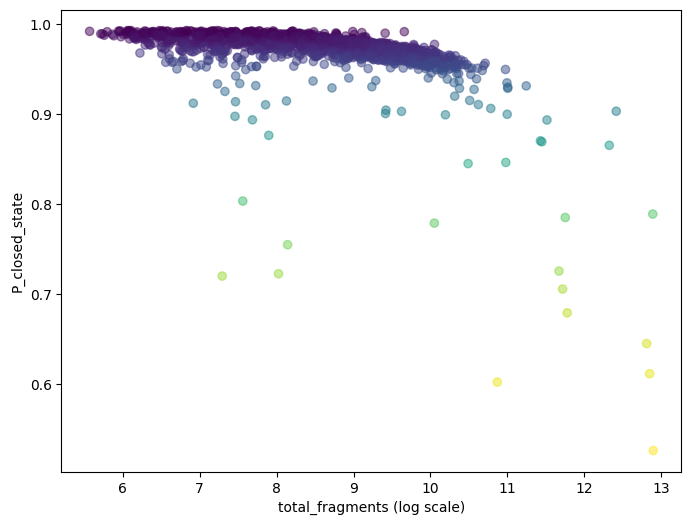

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
v1 = ax.scatter(np.log(union_cell_info['total_fragments']), union_cell_info['P_closed_state'], alpha=0.5,
                c = union_cell_info['Entropy'],)
ax.set_xlabel('total_fragments (log scale)')
ax.set_ylabel('P_closed_state')

Text(0, 0.5, 'P_closed_state')

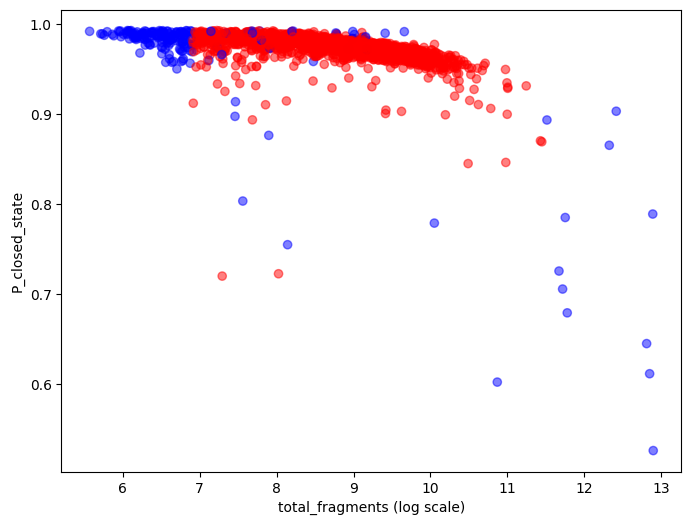

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
v1 = ax.scatter(np.log(union_cell_info['total_fragments']), union_cell_info['P_closed_state'], alpha=0.5,
                c = union_cell_info['atac_pass_archr_TSS'].map({True: 'red', False: 'blue'}),)
ax.set_xlabel('total_fragments (log scale)')
ax.set_ylabel('P_closed_state')

In [13]:
union_cell_info.groupby(['atac_pass_entropy', 'atac_pass_archr_TSS']).size().unstack()

atac_pass_archr_TSS,False,True
atac_pass_entropy,,
False,61,222
True,191,1910


In [14]:
union_cell_info['stringent_cell_calling'] = union_cell_info['P_closed_state'] > 0.8

union_cell_info.groupby(['stringent_cell_calling', 'atac_pass_archr_TSS']).size().unstack()

atac_pass_archr_TSS,False,True
stringent_cell_calling,,
False,72,224
True,180,1908


In [15]:
union_cell_info.groupby(['stringent_cell_calling', 'atac_pass_entropy']).size().unstack()

atac_pass_entropy,False,True
stringent_cell_calling,,
False,283.0,13.0
True,NaN,2088.0


In [16]:
union_cell_info.to_csv('/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/Union_cell_3set_with_stringent_calling.tsv', sep='\t')

NameError: name 'a' is not defined

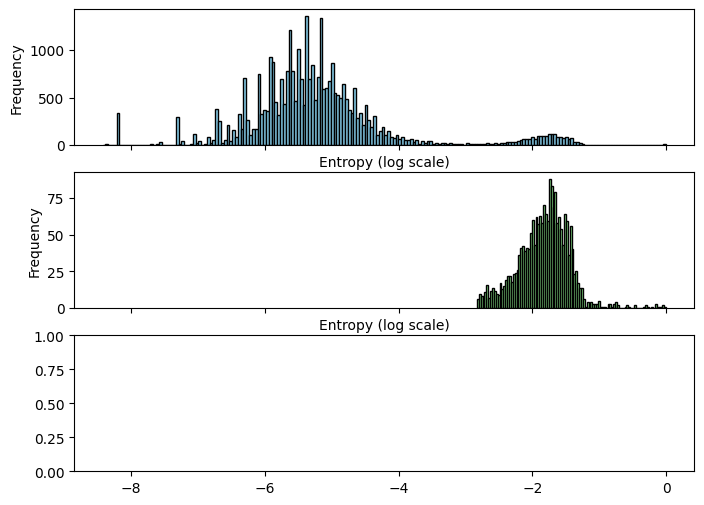

In [17]:
fig, ax = plt.subplots(figsize=(8, 6), nrows=3, ncols=1, sharex=True)
xlims = min(np.log(entropy_all['Entropy'].min()), np.log(entropy_df['Entropy'].min()))

_ = ax[0].hist(np.log(entropy_all['Entropy']), bins=200, color='skyblue', edgecolor='black')
_ = ax[1].hist(np.log(entropy_df['Entropy']), bins=100, color='lightgreen', edgecolor='black')


ax[0].set_xlabel('Entropy (log scale)')
ax[0].set_ylabel('Frequency')

ax[1].set_xlabel('Entropy (log scale)')
ax[1].set_ylabel('Frequency')

ax[2].scatter(np.log(a['Entropy']),
              np.log(a['total_fragments']),
                alpha=0.5, s= 5,
                c=a['P_closed_state'])
ax[2].set_xlabel('Entropy (log scale)')
ax[2].set_ylabel('Total Fragments (log scale)')
ax[2].set_xlim(xlims)
cbar = plt.colorbar(ax[2].collections[0], ax=ax[2],orientation="horizontal", pad=0.3,)
cbar.set_label('P_closed_state')
plt.tight_layout()
